1. Importing Packages

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import plot_model

2. Architecture Diagram

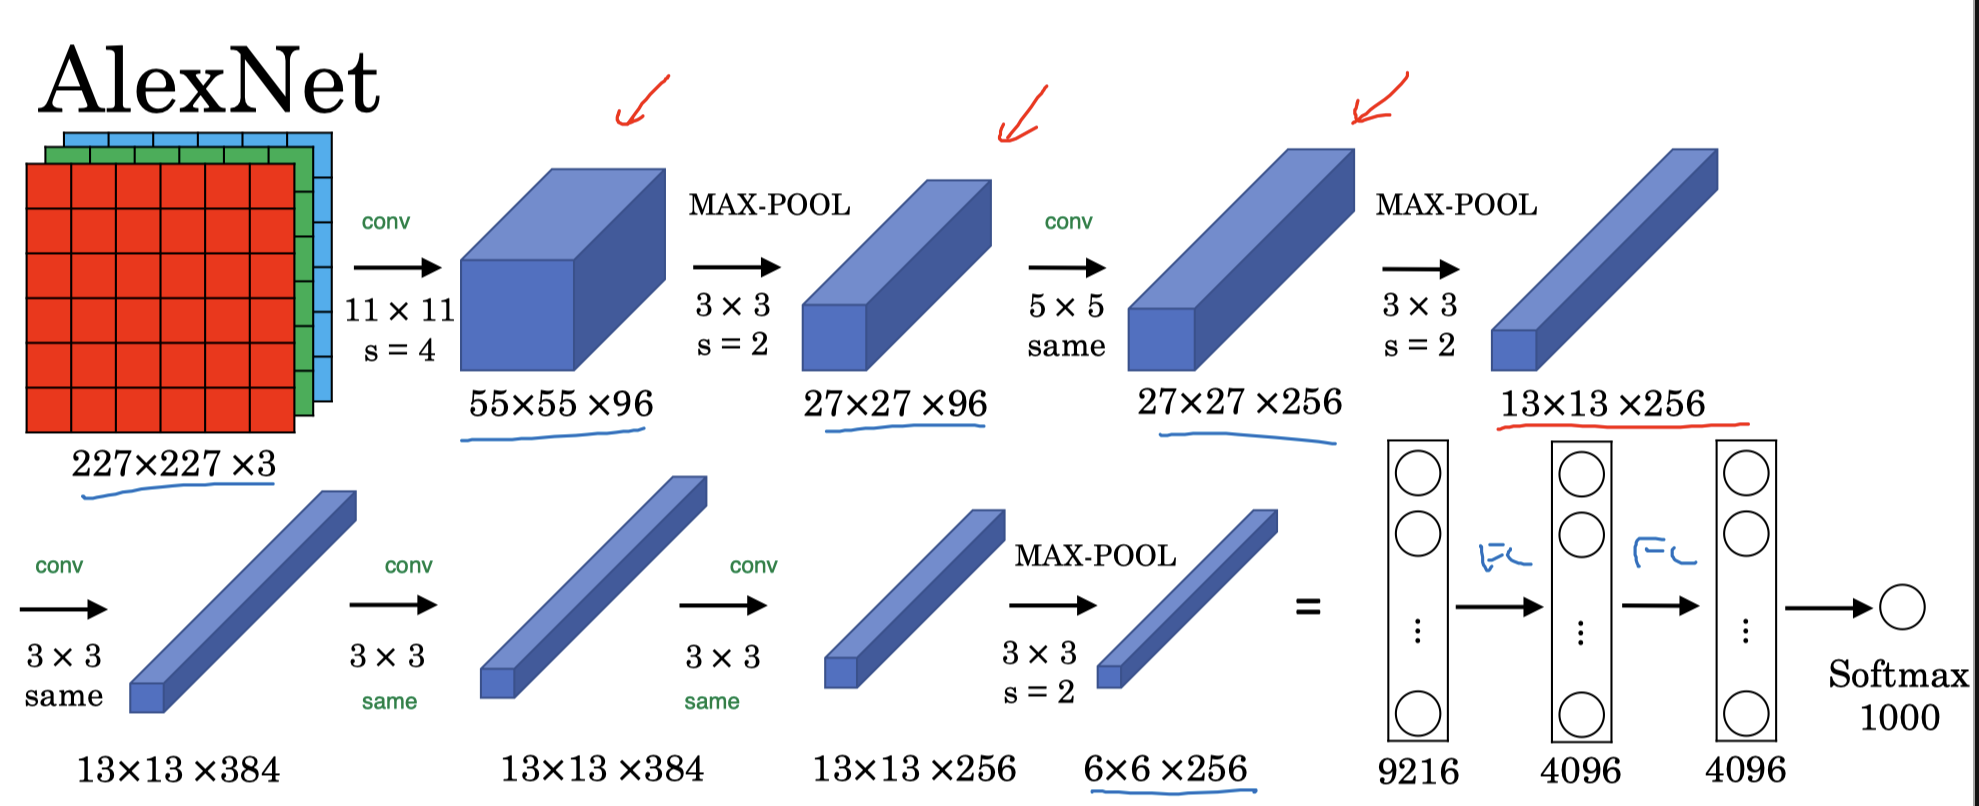

3. Implementing Architecture

In [2]:
def building_alexnet(input_shape=(227,227,3), num_classes=1000):
    inputs = layers.Input(shape=input_shape)

    # no padding applied in below Conv2D layer
    x = layers.Conv2D(filters=96, kernel_size=(11,11), strides=4, padding='valid', name='conv1')(inputs)
    x = layers.BatchNormalization(name='BatchNorm1')(x)
    x = layers.Activation('relu', name='relu1')(x)

    # Local Response Normalization
    # # LRN1 (AlexNet params)
    # x = layers.Lambda(
    #     lambda t: tf.nn.local_response_normalization(
    #         t, depth_radius=2, bias=2.0, alpha=1e-4, beta=0.75
    #     ),
    #     name="lrn1",
    # )(x)

    # Using Batch Normalization instead of Local Response Normalization
    

    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='valid', name='pool1') (x)

    # Padding of 2 applied in below Conv2D layer
    x = layers.Conv2D(filters=256, kernel_size=(5,5), strides=1 , padding='same', groups=2, name='conv2') (x)
    x = layers.BatchNormalization(name='BatchNorm2')(x)
    x = layers.Activation('relu', name='relu2')(x)

    # LRN2
    # x = layers.Lambda(
    #     lambda t: tf.nn.local_response_normalization(
    #         t, depth_radius=2, bias=2.0, alpha=1e-4, beta=0.75
    #     ),
    #     name="lrn2",
    # )(x)

    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='valid', name='pool2')(x)

    # Padding of 1 applied in below Conv2D layer
    x = layers.Conv2D(filters=384, kernel_size=(3,3), strides = 1, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='BatchNorm3')(x)
    x = layers.Activation('relu', name='relu3')(x)

    # Padding of 1 applied in below Conv2D layer
    x = layers.Conv2D(filters=384, kernel_size=(3,3), strides = 1, padding='same', groups=2, name='conv4')(x)
    x = layers.BatchNormalization(name='BatchNorm4')(x)
    x = layers.Activation('relu', name='relu4')(x)

    # Padding of 1 applied in below Conv2D layer
    x = layers.Conv2D(filters=256, kernel_size=(3,3), strides = 1, padding='same', groups=2, name='conv5')(x)
    x = layers.BatchNormalization(name='BatchNorm5')(x)
    x = layers.Activation('relu', name='relu5')(x)

    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='valid', name='pool5')(x)

    x = layers.Flatten(name='flatten')(x)

    x = layers.Dense(units=4096, name='fc6')(x)
    x = layers.Activation('relu', name='relu6')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(units=4096, name='fc7')(x)
    x = layers.Activation('relu', name='relu7')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(units=num_classes, activation='softmax', name='fc8')(x)

    return Model(inputs,outputs,name='AlexNet')


In [3]:
model = building_alexnet()
model.summary()

2026-02-22 14:05:15.946838: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-02-22 14:05:15.946866: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-22 14:05:15.946869: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1771731315.946881 1158239 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1771731315.946901 1158239 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm1 (BatchNormalization) │ (None, 55, 55, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 27, 27, 256)    │       307,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm2 (BatchNormalization) │ (None, 27, 27, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm3 (BatchNormalization) │ (None, 13, 13, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 13, 13, 384)    │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm4 (BatchNormalization) │ (None, 13, 13, 384)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 13, 13, 256)    │       442,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm5 (BatchNormalization) │ (None, 13, 13, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6 (Dense)                     │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu6 (Activation)              │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc7 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu7 (Activation)              │ (None, 4096)           │             

 Total params: 60,970,728 (232.58 MB)

 Trainable params: 60,967,976 (232.57 MB)

 Non-trainable params: 2,752 (10.75 KB)

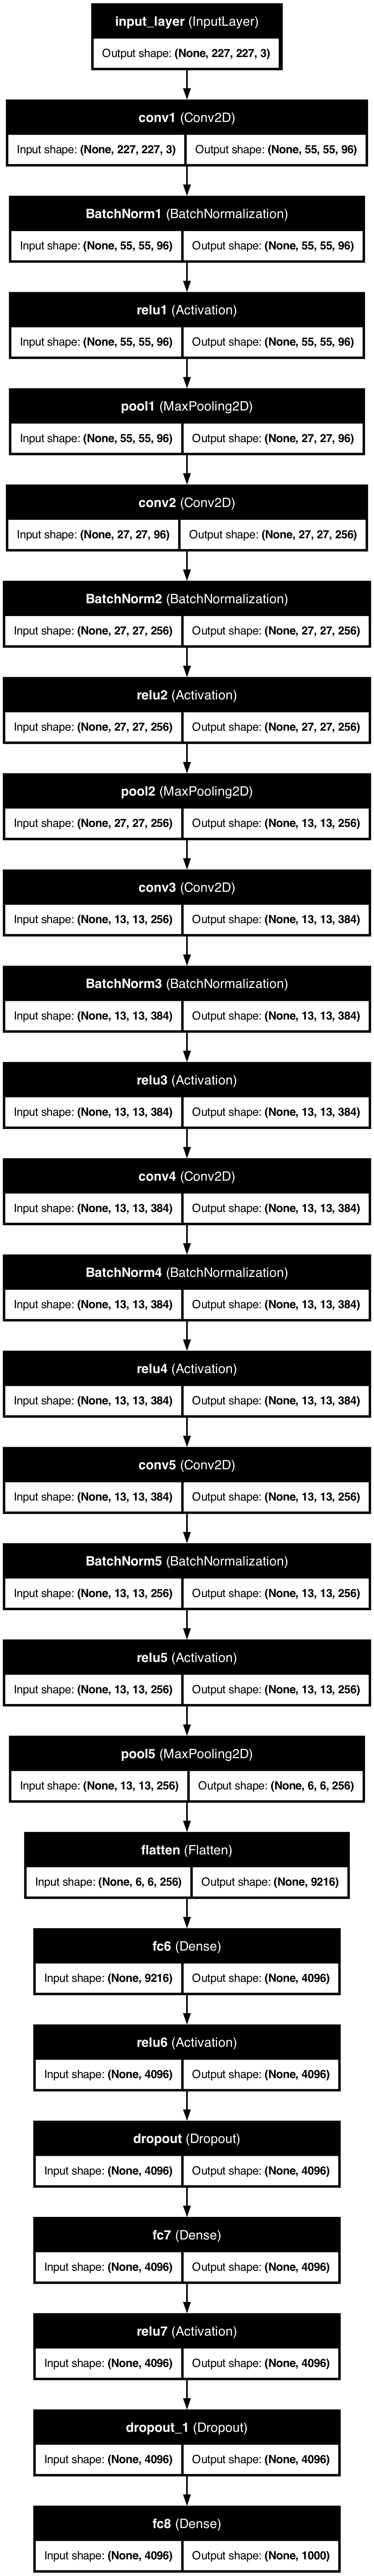

In [4]:
plot_model(model, to_file="model.png",show_layer_names=True,show_shapes=True, rankdir='TB')

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4, 
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Using Adam optimizer instead of Stochastic Gradient Descent.
# model.compile(
#     optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"],
# )

References : 

CNN course by Andrew NG.